# Unit10_Example_Fouriers_Laws_Equation | Fourier's Law 熱量傳遞方程式之數值模擬 (1D / 2D / 3D)

本 Notebook 以 `py-pde` 與 `scipy` 為主要工具，對 Fourier 熱傳方程式進行 1D / 2D / 3D 數值模擬。

## 目標
- 理解 Fourier 第一/第二定律（穩態與非穩態熱傳方程式）的數學形式與物理意義
- 掌握 `py-pde` 的 `DiffusionPDE`、`CartesianGrid`、`CylindricalSymGrid`、`SphericalSymGrid` 的使用方式
- 求解三大邊界條件類型（Dirichlet、Neumann、Robin）下的熱傳 PDE
- 比較數值解與 Fourier 級數解析解，並探討 Fourier 數（ $Fo$ ）與 Biot 數（ $Bi$ ）的影響
- 分析 2D 散熱鰭片效率、3D 非穩態冷卻以及非線性 $k(T)$ 的進階熱傳模型

**配合講義**：`Unit10_Example_Fouriers_Laws_Equation.md`

---
### 0. 環境設定

In [1]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit10_Example_Fouriers_Laws_Equation'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit10'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit10
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit10\outputs\Unit10_Example_Fouriers_Laws_Equation
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit10\outputs\Unit10_Example_Fouriers_Laws_Equation\figs


---
### 1. 載入套件

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy import linalg
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve
from scipy.special import erfc
import pde
import warnings
warnings.filterwarnings('ignore')

# 繪圖樣式設定
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'lines.linewidth': 2,
    'axes.unicode_minus': False,
})

print("✓ 套件載入完成")
print(f"  numpy      版本: {np.__version__}")
import scipy
print(f"  scipy      版本: {scipy.__version__}")
import matplotlib
print(f"  matplotlib 版本: {matplotlib.__version__}")
print(f"  py-pde     版本: {pde.__version__}")

✓ 套件載入完成
  numpy      版本: 1.23.5
  scipy      版本: 1.15.2
  matplotlib 版本: 3.10.8
  py-pde     版本: 0.51.0


---
## Part 1：一維 (1D) 熱傳問題

### 場景一：平板非穩態熱傳導（Transient Heat Conduction in a Finite Slab）

**統御方程式**： $\rho C_p \dfrac{\partial T}{\partial t} = k \dfrac{\partial^2 T}{\partial x^2}$

邊界條件：
- 對稱中心 Neumann： $\partial T/\partial x|_{x=0} = 0$
- 表面 Robin（對流）： $-k \partial T/\partial x|_{x=L} = h(T_L - T_\infty)$

熱擴散率 α = 1.302e-05 m²/s
Biot 數 Bi = 5.00
對應總 Fourier 數 Fo_total = 1.562

✓ Part 1 場景一：求解完成 (8 snapshots)


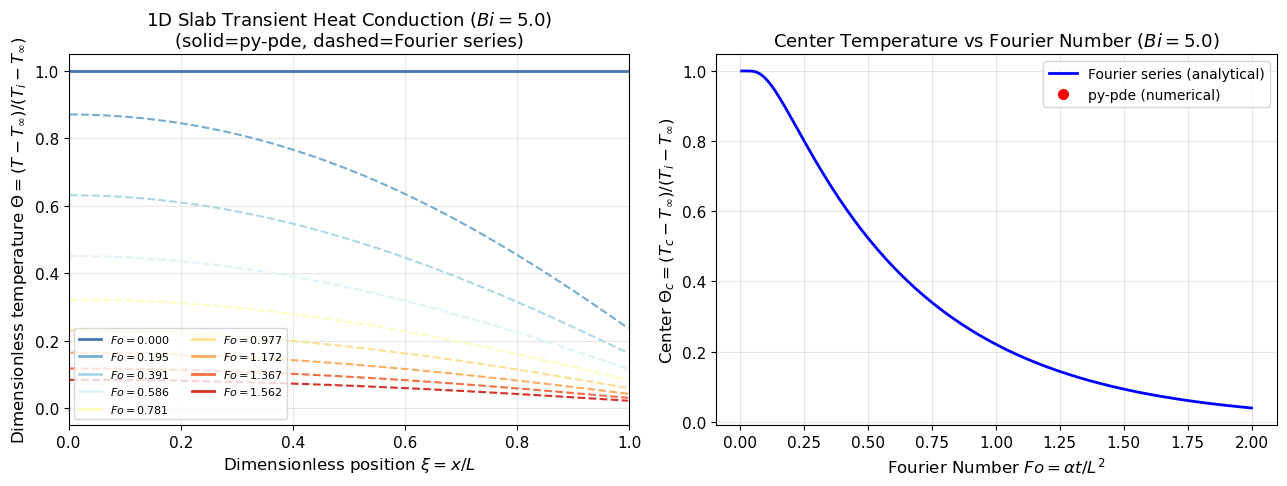

✓ 圖檔已儲存: p1_s1_transient_slab.png


In [3]:
# ============================================================
# Part 1 場景一：平板非穩態熱傳導 + Fourier 級數解析解比對
# ============================================================

# --- 材料與幾何參數（鋼板） ---
k_steel  = 50.0          # 熱傳導係數 [W/m·K]
rho_cp   = 3.84e6        # ρCp [J/m³·K]
alpha    = k_steel / rho_cp   # 熱擴散率 [m²/s]  ≈ 1.302e-5
L        = 0.05          # 半板厚 [m]
h_conv   = 5000.0        # 對流換熱係數 [W/m²·K]
T_i      = 500.0         # 初始溫度 [°C]
T_inf    = 20.0          # 流體溫度 [°C]
Bi       = h_conv * L / k_steel  # Biot 數

t_total  = 300.0         # 模擬總時間 [s]
N_slab   = 200           # 空間格點數

print(f"熱擴散率 α = {alpha:.3e} m²/s")
print(f"Biot 數 Bi = {Bi:.2f}")
print(f"對應總 Fourier 數 Fo_total = {alpha*t_total/L**2:.3f}")

# --- py-pde 建立網格、初始場與 PDE ---
grid_s   = pde.CartesianGrid([[0, L]], shape=N_slab)
T_init_s = pde.ScalarField(grid_s, data=(T_i - T_inf))  # 以超溫 θ=(T-T_inf) 為場變數

# Robin BC: -k dT/dx = h*(T - T_inf)
# py-pde robin bc 格式: {value: a, {derivative: b}} 不直接有 robin，用 mixed 或自訂
# 改用 extrapolate + 手動設 Dirichlet/Neumann 或直接編寫邊界
# 此處以 theta=(T-T_inf) 場：右邊界 Neumann equivalent: dtheta/dx = -(h/k)*theta
bc_s     = [{"derivative": 0},                  # x=0: 對稱，無熱通量
             {"mixed": h_conv / k_steel}]        # x=L: Robin (d theta/dx + Bi/L * theta = 0)

eq_s     = pde.DiffusionPDE(diffusivity=alpha, bc=bc_s)
storage_s = pde.MemoryStorage()
n_shots  = 8
t_shots  = np.linspace(0, t_total, n_shots + 1)[1:]

solved_s = eq_s.solve(T_init_s, t_range=t_total, dt=0.05,
                      tracker=[storage_s.tracker(t_shots)])
print(f"\n✓ Part 1 場景一：求解完成 ({n_shots} snapshots)")

# --- Fourier 級數解析解：特徵方程式 λ*tan(λ) = Bi ---
from scipy.optimize import brentq

def char_eq(lam, Bi):
    return lam * np.tan(lam) - Bi

n_terms  = 30
lambdas  = []
for n in range(n_terms):
    lo = n * np.pi + 1e-8
    hi = (n + 0.5) * np.pi - 1e-8
    try:
        lam = brentq(char_eq, lo, hi, args=(Bi,))
        lambdas.append(lam)
    except ValueError:
        pass
lambdas = np.array(lambdas)

def fourier_theta(xi, Fo, lams, Bi):
    theta = np.zeros_like(xi)
    for lam in lams:
        Cn = 4 * np.sin(lam) / (2 * lam + np.sin(2 * lam))
        theta += Cn * np.cos(lam * xi) * np.exp(-lam**2 * Fo)
    return theta

# --- 繪圖 ---
colors_s = cm.RdYlBu_r(np.linspace(0.1, 0.9, n_shots + 1))
x_s      = grid_s.axes_coords[0]
xi_r     = x_s / L

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 左圖：溫度剖面
ax = axes[0]
# t=0 初始場
ax.plot(xi_r, (T_i - T_inf) * np.ones_like(xi_r) / (T_i - T_inf),
        color=colors_s[0], lw=2, label=f'$Fo=0.000$')

for idx, (t_val, snap) in enumerate(storage_s.items()):
    Fo_s = alpha * t_val / L**2
    theta_num = snap.data / (T_i - T_inf)
    theta_ana = fourier_theta(xi_r, Fo_s, lambdas, Bi)
    ax.plot(xi_r, theta_num, color=colors_s[idx + 1], lw=2,
            label=f'$Fo={Fo_s:.3f}$')
    ax.plot(xi_r, theta_ana, '--', color=colors_s[idx + 1], lw=1.5)

ax.set_xlabel(r'Dimensionless position $\xi = x/L$')
ax.set_ylabel(r'Dimensionless temperature $\Theta = (T-T_\infty)/(T_i-T_\infty)$')
ax.set_title(f'1D Slab Transient Heat Conduction ($Bi={Bi:.1f}$)\n(solid=py-pde, dashed=Fourier series)')
ax.legend(fontsize=8, ncol=2, loc='lower left')
ax.set_xlim(0, 1); ax.set_ylim(-0.05, 1.05)

# 右圖：中心溫度 vs Fo
ax2 = axes[1]
Fo_range = np.linspace(0.005, 2.0, 200)
theta_c_ana = fourier_theta(np.array([0.0]), Fo_range, lambdas, Bi)[0] \
    if False else np.array([fourier_theta(np.array([0.0]), fo, lambdas, Bi)[0] for fo in Fo_range])

Fo_num_s    = []
theta_c_num = []
for t_val, snap in storage_s.items():
    Fo_num_s.append(alpha * t_val / L**2)
    theta_c_num.append(snap.data[0] / (T_i - T_inf))

ax2.plot(Fo_range, theta_c_ana, 'b-', lw=2, label='Fourier series (analytical)')
ax2.plot(Fo_num_s, theta_c_num, 'ro', ms=7, label='py-pde (numerical)')
ax2.set_xlabel('Fourier Number $Fo = \\alpha t / L^2$')
ax2.set_ylabel(r'Center $\Theta_c = (T_c - T_\infty)/(T_i - T_\infty)$')
ax2.set_title(f'Center Temperature vs Fourier Number ($Bi={Bi:.1f}$)')
ax2.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'p1_s1_transient_slab.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ 圖檔已儲存: p1_s1_transient_slab.png")

---
### 場景二：含內部熱源之穩態熱傳導（Steady-State with Volumetric Heat Generation）

**統御方程式**（穩態 Poisson）： $k \dfrac{d^2 T}{d x^2} + \dot{Q} = 0$

**解析解**： $T(x) = \dfrac{\dot{Q}}{2k}(L^2 - x^2) + T_w$

解析解中心最高溫度 T_max = 125.00°C
py-pde 推進法中心溫度: 124.45°C  (計算時間: 7.39s)
scipy 矩陣法中心溫度:   125.00°C  (計算時間: 28.54 ms)


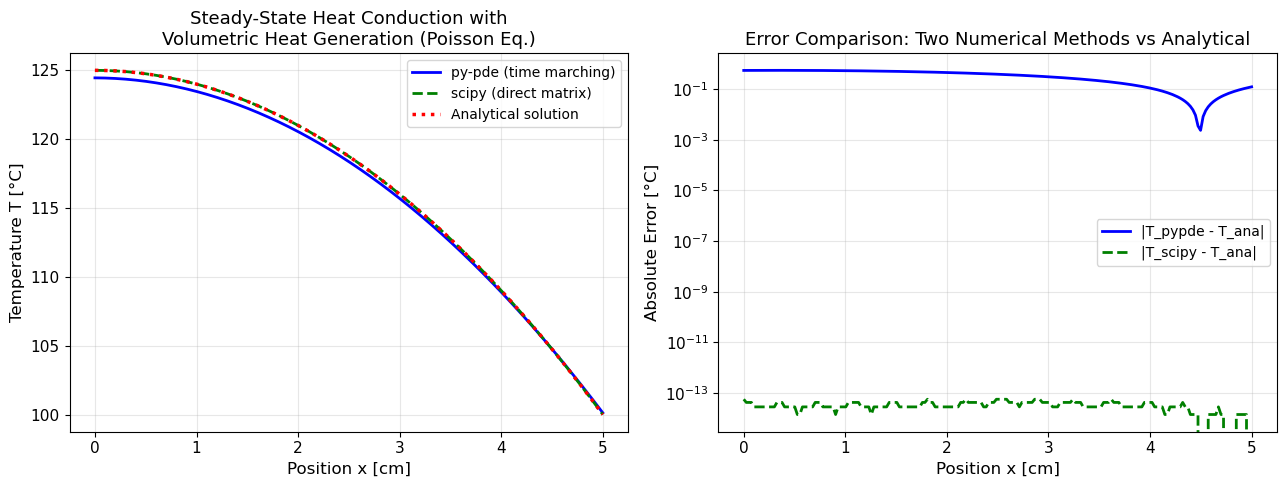


✓ Part 1 場景二：求解完成 | 圖檔已儲存: p1_s2_heat_generation.png


In [4]:
# ============================================================
# Part 1 場景二：含內部熱源穩態熱傳（Poisson 方程式）
# 方法一：py-pde 時間推進至穩態
# 方法二：scipy 直接矩陣法
# ============================================================

import time

# --- 參數 ---
k_gen   = 50.0           # 熱傳導係數 [W/m·K]
L_gen   = 0.05           # 半板厚 [m]
Q_dot   = 1.0e6          # 體積熱源 [W/m³]
T_w     = 100.0          # 外壁溫度 [°C] (Dirichlet)
N_gen   = 200            # 格點數
alpha_g = 1.302e-5       # 熱擴散率 (用於時間推進)

T_max_ana = T_w + Q_dot * L_gen**2 / (2 * k_gen)
print(f"解析解中心最高溫度 T_max = {T_max_ana:.2f}°C")

# --- 方法一：py-pde 時間推進 ---
x_gen    = np.linspace(0, L_gen, N_gen)
grid_gen = pde.CartesianGrid([[0, L_gen]], shape=N_gen)

# dT/dt = alpha * d²T/dx² + Q_dot/(rho*Cp)
# 由於 alpha = k/(rho*Cp)，所以 Q_dot/(rho*Cp) = Q_dot*alpha/k
src_rate = Q_dot * alpha_g / k_gen   # [°C/s]

# 注意：py-pde 0.51 BC 格式需使用位置列表，不可使用欄位名稱字典
eq_gen = pde.PDE(
    {"T": f"{alpha_g} * laplace(T) + {src_rate:.8f}"},
    bc=[{"derivative": 0}, {"value": T_w}]   # 左:對稱(x=0)，右:固壁(x=L)
)

T_init_gen = pde.ScalarField(grid_gen, data=T_w)

t0 = time.time()
result_gen = eq_gen.solve(T_init_gen, t_range=300, tracker=None)
t1 = time.time()
T_pypde = result_gen.data.copy()
print(f"py-pde 推進法中心溫度: {T_pypde[0]:.2f}°C  (計算時間: {t1-t0:.2f}s)")

# --- 方法二：scipy 直接矩陣法 ---
dx_gen = L_gen / (N_gen - 1)
# 方程式（符號慣例 +A*T = b）：
#   i 內部節點: -T_{i-1} + 2T_i - T_{i+1} = Q_dot*dx²/k
#   i=0 對稱 (T_{-1}=T_1): 2T_0 - 2T_1 = Q_dot*dx²/k
#   i=N-1 Dirichlet (T_w 移至右端): b[N-2] += T_w

e = np.ones(N_gen - 1)
A_mat = diags([-e[1:], 2*e, -e[1:]], [-1, 0, 1],
              shape=(N_gen-1, N_gen-1), format='csc').toarray()
A_mat[0, 1] = -2.0   # 對稱邊界修正：ghost cell T_{-1}=T_1

src_vec = np.full(N_gen - 1, Q_dot * dx_gen**2 / k_gen)
src_vec[-1] += T_w    # Dirichlet BC 貢獻

t0 = time.time()
T_scipy = np.linalg.solve(A_mat, src_vec)
T_scipy = np.append(T_scipy, T_w)  # 補上邊界點
t1 = time.time()
print(f"scipy 矩陣法中心溫度:   {T_scipy[0]:.2f}°C  (計算時間: {(t1-t0)*1000:.2f} ms)")

# --- 解析解 ---
T_ana_gen = Q_dot / (2 * k_gen) * (L_gen**2 - x_gen**2) + T_w

# --- 繪圖 ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(x_gen * 100, T_pypde,    'b-',  lw=2, label='py-pde (time marching)')
ax.plot(x_gen * 100, T_scipy,    'g--', lw=2, label='scipy (direct matrix)')
ax.plot(x_gen * 100, T_ana_gen,  'r:',  lw=2.5, label='Analytical solution')
ax.set_xlabel('Position x [cm]')
ax.set_ylabel('Temperature T [°C]')
ax.set_title('Steady-State Heat Conduction with\nVolumetric Heat Generation (Poisson Eq.)')
ax.legend()

ax2 = axes[1]
ax2.plot(x_gen * 100, np.abs(T_pypde - T_ana_gen), 'b-',  lw=2, label='|T_pypde - T_ana|')
ax2.plot(x_gen * 100, np.abs(T_scipy - T_ana_gen), 'g--', lw=2, label='|T_scipy - T_ana|')
ax2.set_xlabel('Position x [cm]')
ax2.set_ylabel('Absolute Error [°C]')
ax2.set_title('Error Comparison: Two Numerical Methods vs Analytical')
ax2.legend()
ax2.set_yscale('log')

plt.tight_layout()
plt.savefig(FIG_DIR / 'p1_s2_heat_generation.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Part 1 場景二：求解完成 | 圖檔已儲存: p1_s2_heat_generation.png")

---
### 場景三：一維非穩態熱傳含 Robin 對流邊界條件

**問題描述**：分析不同 Biot 數（ $Bi = 0.01, 1.0, 100$ ）下，金屬棒一端加熱（Dirichlet）、另一端對流散熱（Robin）的穩態溫度分布，驗證 $Bi$ 數的物理極限行為。

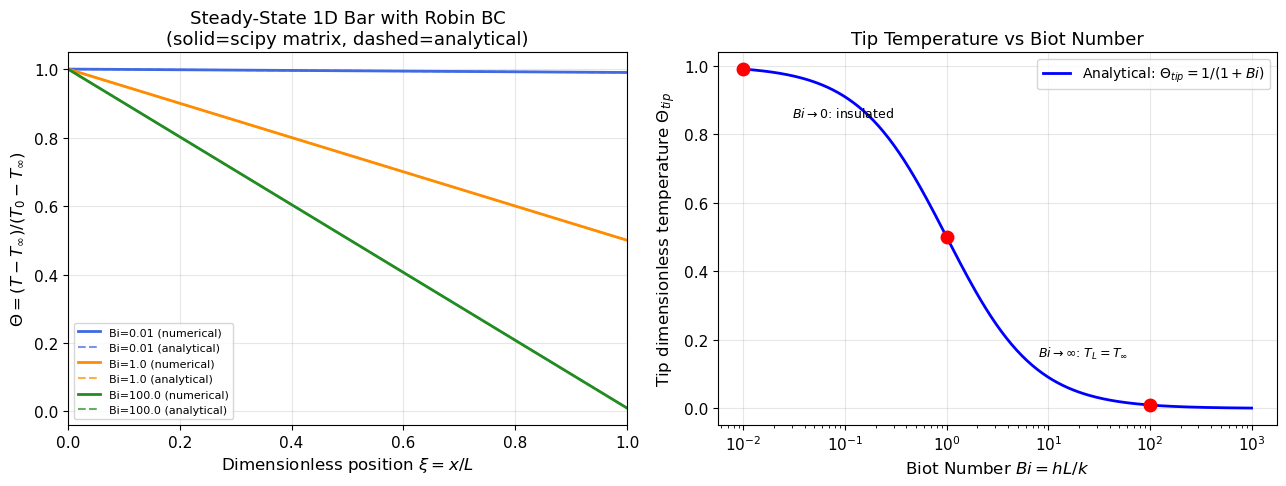

✓ Part 1 場景三：求解完成 | 圖檔已儲存: p1_s3_robin_bc.png


In [5]:
# ============================================================
# Part 1 場景三：一維非穩態熱傳含 Robin 對流邊界條件
# 方法一：scipy 三對角矩陣法（穩態解）
# 方法二：scipy solve_ivp 方法線法（非穩態解）
# ============================================================

from scipy.integrate import solve_ivp
from scipy.sparse import diags as sp_diags

# --- 參數 ---
k_rob    = 50.0          # 熱傳導係數 [W/m·K]
alpha_r  = 1.302e-5      # 熱擴散率 [m²/s]
L_rob    = 0.1           # 棒長 [m]
T_0      = 500.0         # 左端固定溫度 [°C]
T_i_r    = 20.0          # 初始溫度 [°C]
T_inf_r  = 20.0          # 流體溫度 [°C]
N_rob    = 200           # 格點數

Bi_list  = [0.01, 1.0, 100.0]
h_list   = [Bi * k_rob / L_rob for Bi in Bi_list]
labels   = [f'Bi={b}' for b in Bi_list]
colors_r = ['royalblue', 'darkorange', 'forestgreen']

x_r  = np.linspace(0, L_rob, N_rob)
dx_r = x_r[1] - x_r[0]
xi_r = x_r / L_rob

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

Theta_tip_num = []
Bi_ana    = np.logspace(-2, 3, 200)
Theta_ana = 1.0 / (1 + Bi_ana)   # 穩態解析解

for Bi_val, h_val, label, color in zip(Bi_list, h_list, labels, colors_r):

    # --- 方法一：scipy 三對角矩陣（穩態）---
    # 方程式: -T_{i-1} + 2T_i - T_{i+1} = 0 (無熱源)
    # 邊界：i=0: T_0 (Dirichlet)；i=N-1: Robin (以虛擬節點法離散)
    # Robin 右端: -k*(T_N - T_{N-2})/(2*dx) = h*(T_{N-1} - T_inf)
    # → T_N = T_{N-2} - 2*dx*h/k*(T_{N-1} - T_inf)
    # 代入 d²T/dx² = 0 at i=N-1:
    # T_{N-2} - 2*T_{N-1} + T_N = 0
    # T_{N-2} - 2*T_{N-1} + T_{N-2} - 2*dx*h/k*(T_{N-1} - T_inf) = 0
    # 2*T_{N-2} - (2 + 2*dx*h/k)*T_{N-1} = -2*dx*h/k*T_inf

    n   = N_rob  # 包含兩端，共 N 個點
    e   = np.ones(n)
    A_r = sp_diags([-e[1:], 2*e, -e[1:]], [-1, 0, 1],
                   shape=(n, n), format='lil').toarray()
    b_r = np.zeros(n)

    # 左端 Dirichlet: T[0] = T_0
    A_r[0, :] = 0;  A_r[0, 0] = 1;  b_r[0] = T_0
    # 右端 Robin（虛擬節點消去）
    A_r[-1, :]    = 0
    A_r[-1, -2]   = 2.0
    A_r[-1, -1]   = -(2.0 + 2*dx_r*h_val/k_rob)
    b_r[-1]       = -2*dx_r*h_val/k_rob * T_inf_r

    T_ss = np.linalg.solve(A_r, b_r)

    # 解析解（穩態）: T(x) = T_0 + B*x
    B_ana = -h_val*(T_0 - T_inf_r) / (k_rob + h_val*L_rob)
    T_ana_r = T_0 + B_ana * x_r

    Theta_num_ss  = (T_ss  - T_inf_r) / (T_0 - T_inf_r)
    Theta_ana_ss  = (T_ana_r - T_inf_r) / (T_0 - T_inf_r)

    axes[0].plot(xi_r, Theta_num_ss,  '-',  color=color, lw=2,
                 label=f'{label} (numerical)')
    axes[0].plot(xi_r, Theta_ana_ss,  '--', color=color, lw=1.5, alpha=0.7,
                 label=f'{label} (analytical)')

    tip_theta = (T_ss[-1] - T_inf_r) / (T_0 - T_inf_r)
    Theta_tip_num.append((Bi_val, tip_theta))

axes[0].set_xlabel('Dimensionless position $\\xi = x/L$')
axes[0].set_ylabel(r'$\Theta = (T - T_\infty)/(T_0 - T_\infty)$')
axes[0].set_title('Steady-State 1D Bar with Robin BC\n(solid=scipy matrix, dashed=analytical)')
axes[0].legend(fontsize=8)
axes[0].set_xlim([0, 1])

# 右圖：tip 溫度 vs Bi
axes[1].semilogx(Bi_ana, Theta_ana, 'b-', lw=2,
                 label=r'Analytical: $\Theta_{tip}=1/(1+Bi)$')
for Bi_val, tip in Theta_tip_num:
    axes[1].semilogx(Bi_val, tip, 'ro', ms=9)
axes[1].set_xlabel('Biot Number $Bi = hL/k$')
axes[1].set_ylabel(r'Tip dimensionless temperature $\Theta_{tip}$')
axes[1].set_title('Tip Temperature vs Biot Number')
axes[1].legend()
axes[1].annotate('$Bi\\to 0$: insulated', xy=(0.01, 0.99),
                  xytext=(0.03, 0.85), fontsize=9)
axes[1].annotate('$Bi\\to\\infty$: $T_L=T_\\infty$', xy=(100, 0.01),
                  xytext=(8, 0.15), fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / 'p1_s3_robin_bc.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Part 1 場景三：求解完成 | 圖檔已儲存: p1_s3_robin_bc.png")

---
## Part 2：二維 (2D) 熱傳問題

### 場景一：矩形板之穩態二維熱傳（Laplace 方程式）

**統御方程式**： $\dfrac{\partial^2 T}{\partial x^2} + \dfrac{\partial^2 T}{\partial y^2} = 0$

四邊 Dirichlet 邊界條件： $T_L=100°C$ ，$T_R=0°C$ ，$T_B=50°C$ ，$T_T=0°C$

✓ py-pde 2D 穩態求解完成（cell-centered, x_range=[0.010, 0.990] m）
✓ scipy 稀疏矩陣法 2D 穩態求解完成（vertex 格點，含邊界節點）
  （注意：兩方法格點定義不同，py-pde=cell-center，scipy=vertex，僅視覺比較）


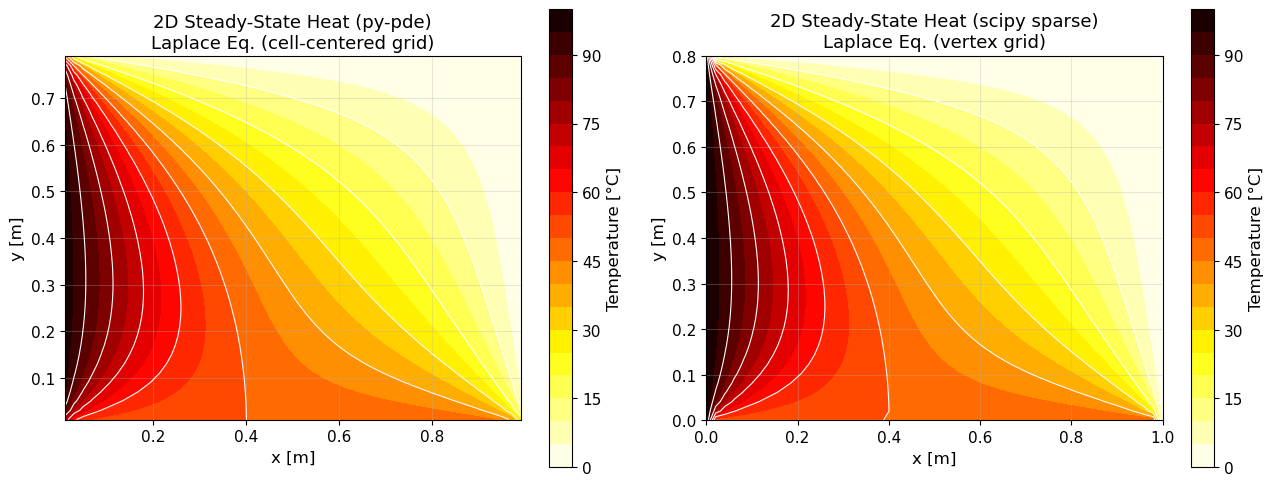

✓ 圖檔已儲存: p2_s1_2d_steady_laplace.png


In [6]:
# ============================================================
# Part 2 場景一：2D 穩態矩形板熱傳（Laplace 方程式）
# 方法一：py-pde 時間推進至穩態（cell-centered 格點）
# 方法二：scipy 稀疏矩陣直接法（vertex 格點含邊界）
# ============================================================

from scipy.sparse import lil_matrix, csr_matrix

# --- 幾何與邊界條件參數 ---
Lx_2d  = 1.0     # 矩形寬 [m]
Ly_2d  = 0.8     # 矩形高 [m]
Nx_2d  = 50      # x 方向格點
Ny_2d  = 40      # y 方向格點
T_L2   = 100.0   # 左邊 x=0 溫度 [°C]
T_R2   = 0.0     # 右邊 x=Lx 溫度 [°C]
T_B2   = 50.0    # 下邊 y=0 溫度 [°C]
T_T2   = 0.0     # 上邊 y=Ly 溫度 [°C]

# --- 方法一：py-pde 2D 時間推進至穩態 ---
# py-pde 使用 cell-centered 格點：座標為 [dx/2, 3dx/2, ..., Lx-dx/2]
grid_2d   = pde.CartesianGrid([[0, Lx_2d], [0, Ly_2d]], shape=[Nx_2d, Ny_2d])
x_pypde   = grid_2d.axes_coords[0]   # cell centers, shape (Nx_2d,)
y_pypde   = grid_2d.axes_coords[1]   # cell centers, shape (Ny_2d,)
bc_2d     = [[{"value": T_L2}, {"value": T_R2}],    # x 方向
              [{"value": T_B2}, {"value": T_T2}]]    # y 方向
eq_2d     = pde.DiffusionPDE(diffusivity=1.0, bc=bc_2d)
T_init_2d = pde.ScalarField(grid_2d, data=25.0)
result_2d  = eq_2d.solve(T_init_2d, t_range=2, tracker=None)
T_pypde_2d = result_2d.data.copy()   # shape (Nx_2d, Ny_2d)
print("✓ py-pde 2D 穩態求解完成（cell-centered, "
      f"x_range=[{x_pypde[0]:.3f}, {x_pypde[-1]:.3f}] m）")

# --- 方法二：scipy 稀疏矩陣法（vertex 格點，含邊界節點）---
dx2      = Lx_2d / (Nx_2d - 1)
dy2      = Ly_2d / (Ny_2d - 1)
x_scipy  = np.linspace(0, Lx_2d, Nx_2d)
y_scipy  = np.linspace(0, Ly_2d, Ny_2d)

def ij2k(i, j, Ny):
    return i * Ny + j

N_tot  = Nx_2d * Ny_2d
A_sp   = lil_matrix((N_tot, N_tot))
b_sp   = np.zeros(N_tot)

for i in range(Nx_2d):
    for j in range(Ny_2d):
        k = ij2k(i, j, Ny_2d)
        if i == 0:
            A_sp[k, k] = 1.0; b_sp[k] = T_L2
        elif i == Nx_2d - 1:
            A_sp[k, k] = 1.0; b_sp[k] = T_R2
        elif j == 0:
            A_sp[k, k] = 1.0; b_sp[k] = T_B2
        elif j == Ny_2d - 1:
            A_sp[k, k] = 1.0; b_sp[k] = T_T2
        else:
            A_sp[k, k]                    = -2/dx2**2 - 2/dy2**2
            A_sp[k, ij2k(i-1, j, Ny_2d)] =  1/dx2**2
            A_sp[k, ij2k(i+1, j, Ny_2d)] =  1/dx2**2
            A_sp[k, ij2k(i, j-1, Ny_2d)] =  1/dy2**2
            A_sp[k, ij2k(i, j+1, Ny_2d)] =  1/dy2**2

T_flat      = spsolve(csr_matrix(A_sp), b_sp)
T_scipy_2d  = T_flat.reshape(Nx_2d, Ny_2d)
print("✓ scipy 稀疏矩陣法 2D 穩態求解完成（vertex 格點，含邊界節點）")
print("  （注意：兩方法格點定義不同，py-pde=cell-center，scipy=vertex，僅視覺比較）")

# --- 繪圖（各自使用正確的座標）---
levels_2d = np.linspace(0, 100, 21)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cf1 = axes[0].contourf(x_pypde, y_pypde, T_pypde_2d.T,
                        levels=levels_2d, cmap='hot_r')
axes[0].contour(x_pypde, y_pypde, T_pypde_2d.T,
                levels=levels_2d[::2], colors='white', linewidths=0.8)
plt.colorbar(cf1, ax=axes[0], label='Temperature [°C]')
axes[0].set_xlabel('x [m]'); axes[0].set_ylabel('y [m]')
axes[0].set_title('2D Steady-State Heat (py-pde)\nLaplace Eq. (cell-centered grid)')
axes[0].set_aspect('equal')

cf2 = axes[1].contourf(x_scipy, y_scipy, T_scipy_2d.T,
                        levels=levels_2d, cmap='hot_r')
axes[1].contour(x_scipy, y_scipy, T_scipy_2d.T,
                levels=levels_2d[::2], colors='white', linewidths=0.8)
plt.colorbar(cf2, ax=axes[1], label='Temperature [°C]')
axes[1].set_xlabel('x [m]'); axes[1].set_ylabel('y [m]')
axes[1].set_title('2D Steady-State Heat (scipy sparse)\nLaplace Eq. (vertex grid)')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.savefig(FIG_DIR / 'p2_s1_2d_steady_laplace.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ 圖檔已儲存: p2_s1_2d_steady_laplace.png")

---
### 場景二：矩形板之非穩態二維熱傳（2D Transient Heat Conduction）

初始均勻溫度 $T_i = 25°C$ ，四邊突然施加與場景一相同的 Dirichlet 邊界條件，觀察溫度場的動態演化過程。

✓ 2D 非穩態求解完成 (5 時刻快照)


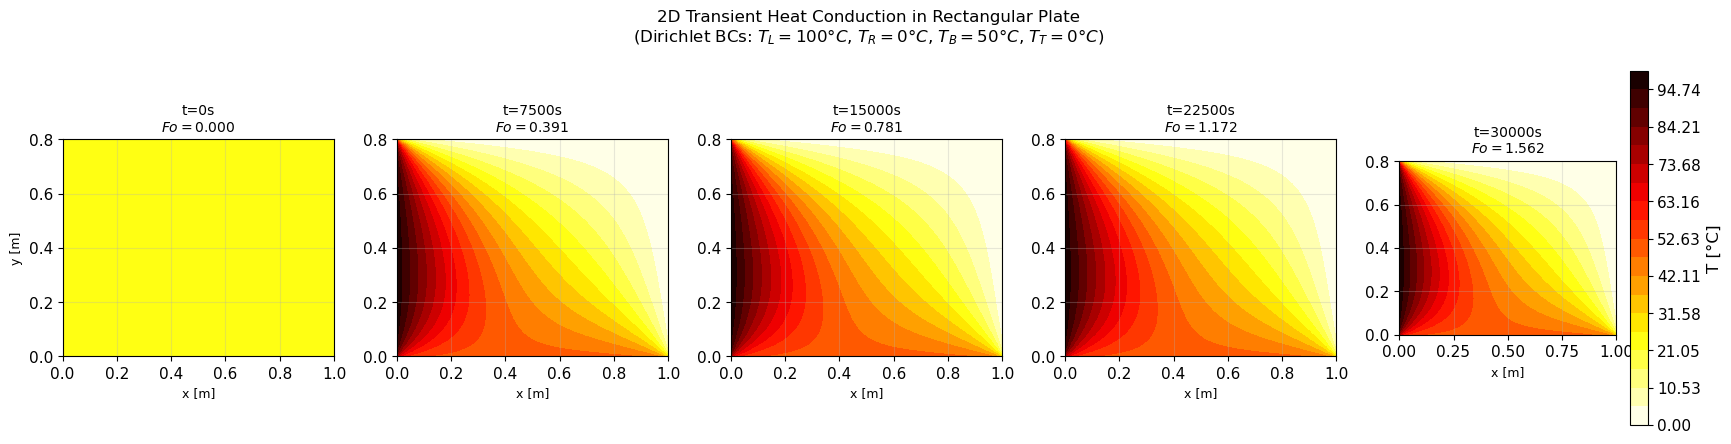

✓ 圖檔已儲存: p2_s2_2d_transient.png


In [7]:
# ============================================================
# Part 2 場景二：2D 非穩態矩形板熱傳 + 能量守恆驗證
# ============================================================

alpha_2d = 1.302e-5   # 熱擴散率 [m²/s]
T_i_2d   = 25.0       # 初始均勻溫度 [°C]
t_total_2d = 3e4      # s 模擬時間

grid_2d2  = pde.CartesianGrid([[0, Lx_2d], [0, Ly_2d]], shape=[Nx_2d, Ny_2d])
bc_2d2    = [[{"value": T_L2}, {"value": T_R2}],
              [{"value": T_B2}, {"value": T_T2}]]
eq_2d2    = pde.DiffusionPDE(diffusivity=alpha_2d, bc=bc_2d2)
T_init_2d2 = pde.ScalarField(grid_2d2, data=T_i_2d)

storage_2d2 = pde.MemoryStorage()
n_shots_2d  = 4
t_shots_2d  = np.linspace(0, t_total_2d, n_shots_2d + 1)[1:]

result_2d2 = eq_2d2.solve(T_init_2d2, t_range=t_total_2d, dt=1.0,
                           tracker=[storage_2d2.tracker(t_shots_2d)])
print(f"✓ 2D 非穩態求解完成 ({n_shots_2d+1} 時刻快照)")

# --- 繪圖：時間快照 ---
t_all    = [0] + list(t_shots_2d)
T_all    = [T_init_2d2.data] + [snap.data for _, snap in storage_2d2.items()]
Fo_2d_all = [alpha_2d * t / (Lx_2d/2)**2 for t in t_all]

x_arr_2 = np.linspace(0, Lx_2d, Nx_2d)
y_arr_2 = np.linspace(0, Ly_2d, Ny_2d)

fig, axes = plt.subplots(1, n_shots_2d + 1, figsize=(3.5 * (n_shots_2d + 1), 4.5))
vmin_2d = 0; vmax_2d = 100

for idx, (T_snap, Fo_val) in enumerate(zip(T_all, Fo_2d_all)):
    im = axes[idx].contourf(x_arr_2, y_arr_2, T_snap.T,
                             levels=np.linspace(vmin_2d, vmax_2d, 20),
                             cmap='hot_r', vmin=vmin_2d, vmax=vmax_2d)
    axes[idx].set_title(f't={t_all[idx]:.0f}s\n$Fo={Fo_val:.3f}$', fontsize=10)
    axes[idx].set_xlabel('x [m]', fontsize=9)
    if idx == 0:
        axes[idx].set_ylabel('y [m]', fontsize=9)
    axes[idx].set_aspect('equal')

plt.colorbar(im, ax=axes[-1], label='T [°C]')
plt.suptitle('2D Transient Heat Conduction in Rectangular Plate\n'
             '(Dirichlet BCs: $T_L=100°C$, $T_R=0°C$, $T_B=50°C$, $T_T=0°C$)',
             fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / 'p2_s2_2d_transient.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ 圖檔已儲存: p2_s2_2d_transient.png")

---
### 場景三：圓柱座標軸對稱 2D 熱傳（CylindricalSymGrid）

有限長圓柱體（ $R=0.05$ m ，$H=0.1$ m ），外表面與端面施加 Dirichlet 冷卻邊界（ $T_{surface}=T_\infty=20°C$ ），分析 $(r,z)$ 截面溫度場的時間演化。

✓ 圓柱座標 2D 熱傳求解完成（τ≈19.5s，共 3 快照）


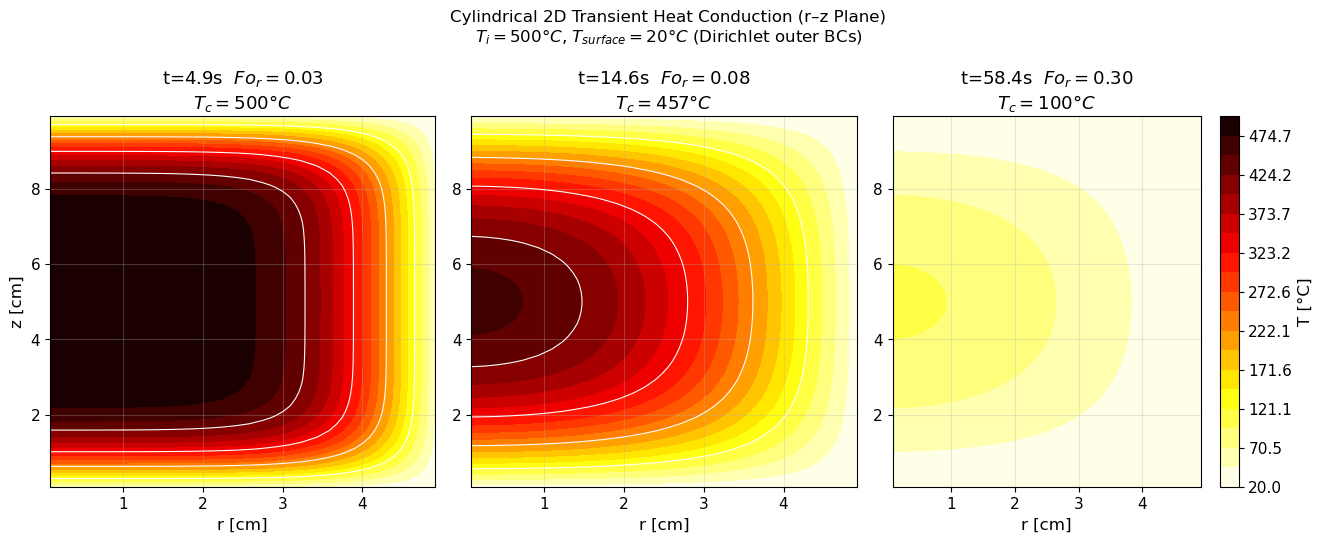

✓ 圖檔已儲存: p2_s3_cylindrical_2d.png


In [8]:
# ============================================================
# Part 2 場景三：圓柱座標軸對稱 2D 熱傳
# py-pde CylindricalSymGrid : (r, z) 平面
# BC：r=0 對稱，r=R 與端面 Dirichlet T=T_inf
# ============================================================

k_cyl    = 50.0        # W/m·K
alpha_c  = 1.302e-5    # m²/s
R_cyl    = 0.05        # 半徑 [m]
H_cyl    = 0.1         # 高 [m]
T_i_cyl  = 500.0       # 初始溫度 [°C]
T_inf_c  = 20.0        # 表面溫度 [°C]
Nr_c     = 30
Nz_c     = 60

# 時間尺度 τ = R²/(π²·α) ≈ 19.4s，設置 3 個快照在 1/4τ, 3/4τ, 3τ
tau_r     = R_cyl**2 / (np.pi**2 * alpha_c)   # ≈ 19.4 s
t_snaps   = np.array([0.25, 0.75, 3.0]) * tau_r
t_total_c = t_snaps[-1] * 1.05

# py-pde 0.51: CylindricalSymGrid(radius, bounds_z, shape)
grid_cyl  = pde.CylindricalSymGrid(radius=R_cyl,
                                    bounds_z=[0, H_cyl],
                                    shape=[Nr_c, Nz_c])

bc_cyl = {
    "r": [{"derivative": 0}, {"value": T_inf_c}],
    "z": [{"value": T_inf_c}, {"value": T_inf_c}]
}

eq_cyl   = pde.DiffusionPDE(diffusivity=alpha_c, bc=bc_cyl)
T_init_c = pde.ScalarField(grid_cyl, data=T_i_cyl)

storage_cyl = pde.MemoryStorage()
eq_cyl.solve(T_init_c, t_range=t_total_c,
             tracker=[storage_cyl.tracker(t_snaps)])

snaps_cyl = list(storage_cyl.items())
print(f"✓ 圓柱座標 2D 熱傳求解完成（τ≈{tau_r:.1f}s，共 {len(snaps_cyl)} 快照）")

# --- 繪圖 ---
r_cyl_arr = grid_cyl.axes_coords[0]
z_cyl_arr = grid_cyl.axes_coords[1]

fig, axes = plt.subplots(1, len(snaps_cyl), figsize=(4.5 * len(snaps_cyl), 5.5))
levels_cyl = np.linspace(T_inf_c, T_i_cyl, 20)

for idx, (t_val, snap) in enumerate(snaps_cyl):
    cf = axes[idx].contourf(r_cyl_arr * 100, z_cyl_arr * 100,
                             snap.data.T, levels=levels_cyl, cmap='hot_r')
    axes[idx].contour(r_cyl_arr * 100, z_cyl_arr * 100,
                      snap.data.T, levels=levels_cyl[::4],
                      colors='white', linewidths=0.8)
    if idx == len(snaps_cyl) - 1:
        plt.colorbar(cf, ax=axes[idx], label='T [°C]')
    axes[idx].set_xlabel('r [cm]')
    axes[idx].set_ylabel('z [cm]' if idx == 0 else '')
    Fo_c = alpha_c * t_val / R_cyl**2
    T_center = snap.data[0, Nz_c // 2]
    axes[idx].set_title(f't={t_val:.1f}s  $Fo_r={Fo_c:.2f}$\n$T_c={T_center:.0f}°C$')

fig.suptitle('Cylindrical 2D Transient Heat Conduction (r–z Plane)\n'
             r'$T_i=500°C$, $T_{surface}=20°C$ (Dirichlet outer BCs)',
             fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / 'p2_s3_cylindrical_2d.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ 圖檔已儲存: p2_s3_cylindrical_2d.png")

---
### 場景四：含對流換熱之 2D 散熱鰭片分析（Heat Fin Efficiency）

計算矩形散熱鰭片的穩態溫度分布與鰭片效率 $\eta_f = Q_{actual}/Q_{max}$ ，並與 1D 解析解比較。

鰭片參數 m = 20.0000 m⁻¹
m*L = 2.000
鰭片效率 η_f = 0.4570 (45.70%)
1D 解析解效率 η_f = 0.4820


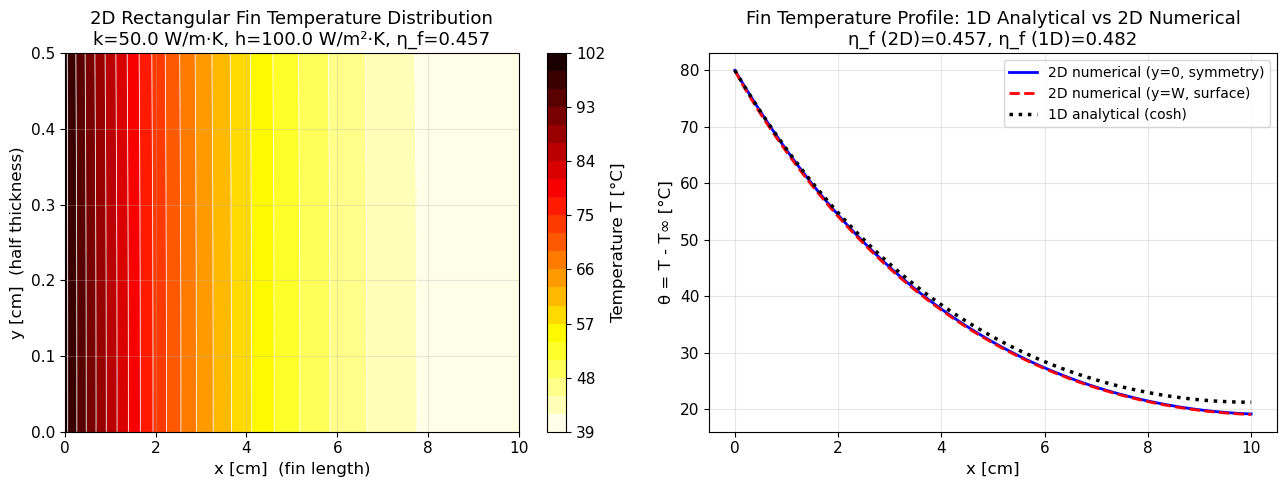

✓ 圖檔已儲存: p2_s4_heat_fin.png


In [9]:
# ============================================================
# Part 2 場景四：2D 散熱鰭片分析 + 鰭片效率計算
# ============================================================

k_fin   = 50.0         # 鰭片熱傳導係數 [W/m·K]
h_fin   = 100.0        # 對流換熱係數 [W/m²·K]
L_f     = 0.1          # 鰭片長度 [m]
W_f     = 0.005        # 鰭片半厚 [m]
T_b     = 100.0        # 基部溫度 [°C]
T_inf_f = 20.0         # 流體溫度 [°C]

Nxf     = 100          # x 格點數（長度方向）
Nyf     = 20           # y 格點數（厚度方向）

# 鰭片參數 m = sqrt(2h/(k*W)) 单面散热
m_fin   = np.sqrt(2 * h_fin / (k_fin * (2 * W_f)))
print(f"鰭片參數 m = {m_fin:.4f} m⁻¹")
print(f"m*L = {m_fin * L_f:.3f}")

# --- scipy 稀疏矩陣法求解穩態 Laplace ---
dx_f = L_f / (Nxf - 1)
dy_f = W_f / (Nyf - 1)   # 取半鰭
x_f  = np.linspace(0, L_f, Nxf)
y_f  = np.linspace(0, W_f, Nyf)

def ij2k_f(i, j):
    return i * Nyf + j

N_f  = Nxf * Nyf
A_f  = lil_matrix((N_f, N_f))
b_f  = np.zeros(N_f)

for i in range(Nxf):
    for j in range(Nyf):
        k_ = ij2k_f(i, j)
        # 基部邊界 x=0
        if i == 0:
            A_f[k_, k_] = 1.0; b_f[k_] = T_b - T_inf_f
        # 端面 x=L_f: Robin (-k dT/dx = h*T)
        elif i == Nxf - 1:
            A_f[k_, k_]            = k_fin / dx_f + h_fin
            A_f[k_, ij2k_f(i-1,j)] = -k_fin / dx_f
            b_f[k_] = 0.0
        # 對稱面 y=0 (半鰭): Neumann dT/dy=0
        elif j == 0:
            A_f[k_, k_]            = -2/dx_f**2 - 2/dy_f**2
            A_f[k_, ij2k_f(i-1,j)] =  1/dx_f**2
            A_f[k_, ij2k_f(i+1,j)] =  1/dx_f**2
            A_f[k_, ij2k_f(i,j+1)] =  2/dy_f**2
        # 上表面 y=W_f: Robin
        elif j == Nyf - 1:
            A_f[k_, k_]            =  k_fin / dy_f + h_fin
            A_f[k_, ij2k_f(i,j-1)] = -k_fin / dy_f
            b_f[k_] = 0.0
        # 內部節點
        else:
            A_f[k_, k_]              = -2/dx_f**2 - 2/dy_f**2
            A_f[k_, ij2k_f(i-1,j)]  =  1/dx_f**2
            A_f[k_, ij2k_f(i+1,j)]  =  1/dx_f**2
            A_f[k_, ij2k_f(i,j-1)]  =  1/dy_f**2
            A_f[k_, ij2k_f(i,j+1)]  =  1/dy_f**2

theta_f_flat = spsolve(csr_matrix(A_f), b_f)
theta_f_2d   = theta_f_flat.reshape(Nxf, Nyf)  # θ = T - T_inf
T_f_2d       = theta_f_2d + T_inf_f

# --- 鰭片效率 ---
# 實際散熱：三面散熱量（端面 + 上下表面）
dA_x = dy_f * 1.0  # 端面單位深度面積
dA_y = dx_f * 1.0  # 側面單位深度面積

Q_end     = h_fin * theta_f_2d[-1, :].mean() * (2 * W_f)   # 端面（兩側）
Q_top_bot = h_fin * np.trapz(theta_f_2d[:, -1], x_f) * 2   # 上+下面
Q_actual  = Q_end + Q_top_bot
Q_max     = h_fin * (T_b - T_inf_f) * (2 * W_f + 2 * L_f + 2 * W_f)  # 若全面都是 T_b
eta_f     = Q_actual / (h_fin * (T_b - T_inf_f) * (2 * L_f + 2 * W_f))
print(f"鰭片效率 η_f = {eta_f:.4f} ({eta_f*100:.2f}%)")

# 1D 解析解效率
eta_f_1d = np.tanh(m_fin * L_f) / (m_fin * L_f)
print(f"1D 解析解效率 η_f = {eta_f_1d:.4f}")

# --- 繪圖 ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cf_f = axes[0].contourf(x_f * 100, y_f * 100, T_f_2d.T,
                         levels=20, cmap='hot_r')
axes[0].contour(x_f * 100, y_f * 100, T_f_2d.T,
                levels=20, colors='white', linewidths=0.6)
plt.colorbar(cf_f, ax=axes[0], label='Temperature T [°C]')
axes[0].set_xlabel('x [cm]  (fin length)')
axes[0].set_ylabel('y [cm]  (half thickness)')
axes[0].set_title(f'2D Rectangular Fin Temperature Distribution\n'
                   f'k={k_fin} W/m·K, h={h_fin} W/m²·K, η_f={eta_f:.3f}')

# 1D 解析解 vs 2D 數值解中線比較
theta_1d_ana = (T_b - T_inf_f) * np.cosh(m_fin * (L_f - x_f)) / np.cosh(m_fin * L_f)
axes[1].plot(x_f * 100, theta_f_2d[:, 0], 'b-',  lw=2, label='2D numerical (y=0, symmetry)')
axes[1].plot(x_f * 100, theta_f_2d[:, -1], 'r--', lw=2, label='2D numerical (y=W, surface)')
axes[1].plot(x_f * 100, theta_1d_ana, 'k:',  lw=2.5, label='1D analytical (cosh)')
axes[1].set_xlabel('x [cm]')
axes[1].set_ylabel('θ = T - T∞ [°C]')
axes[1].set_title('Fin Temperature Profile: 1D Analytical vs 2D Numerical\n'
                   f'η_f (2D)={eta_f:.3f}, η_f (1D)={eta_f_1d:.3f}')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'p2_s4_heat_fin.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ 圖檔已儲存: p2_s4_heat_fin.png")

---
## Part 3：三維 (3D) 熱傳問題

### 場景一：3D 立方體之非穩態熱傳導

初始高溫立方體六面施加 Dirichlet 冷卻邊界（ $T_{surface}=T_\infty$ ），使用 `py-pde` 3D `CartesianGrid` 求解，並以 3D Heisler 乘積法驗證（ $\Theta_{3D} = \Theta_x \cdot \Theta_y \cdot \Theta_z$ ）。

網格總點數: 8,000
✓ 3D 立方體求解完成


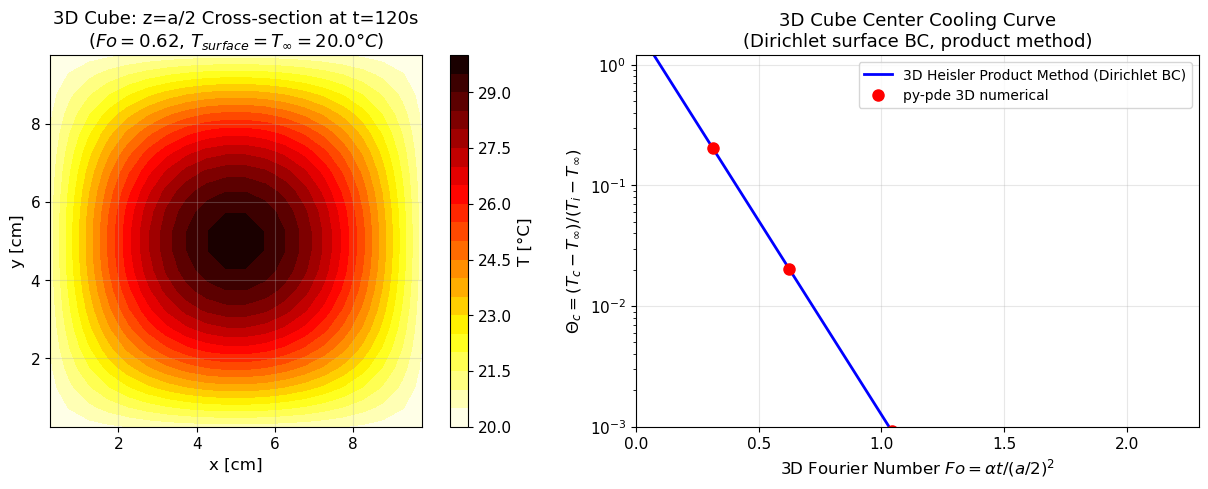

✓ 圖檔已儲存: p3_s1_3d_cube.png


In [10]:
# ============================================================
# Part 3 場景一：3D 立方體非穩態熱傳
# py-pde CartesianGrid (3D) + Dirichlet BC 六面 (Bi→∞極限)
# 解析驗證：Heisler 乘積法 (fixed surface T = T_inf)
# ============================================================

from scipy.optimize import brentq

a_cube   = 0.1          # 立方體邊長 [m]
k_cube   = 50.0         # W/m·K
alpha_3d = 1.302e-5     # m²/s
T_i_3d   = 500.0        # 初始溫度 [°C]
T_inf_3d = 20.0         # 表面/環境溫度 [°C]
N_cube   = 20           # 每邊格點（20³ = 8,000 節點）
t_3d     = 400.0        # 求解時間 [s]

print(f"網格總點數: {N_cube**3:,}")

# 3D CartesianGrid + Dirichlet BC 六面
grid_3d   = pde.CartesianGrid([[0, a_cube]] * 3, shape=[N_cube] * 3)
bc_3d = {
    "x": [{"value": T_inf_3d}, {"value": T_inf_3d}],
    "y": [{"value": T_inf_3d}, {"value": T_inf_3d}],
    "z": [{"value": T_inf_3d}, {"value": T_inf_3d}]
}
T_init_3d = pde.ScalarField(grid_3d, data=T_i_3d)
eq_3d     = pde.DiffusionPDE(diffusivity=alpha_3d, bc=bc_3d)

storage_3d = pde.MemoryStorage()
t_3d_shots = np.array([60, 120, 200, 400])
eq_3d.solve(T_init_3d, t_range=t_3d,
            tracker=[storage_3d.tracker(t_3d_shots)])
print("✓ 3D 立方體求解完成")

# --- 中心溫度時間序列 ---
cx = N_cube // 2
Fo_3d_arr  = []
theta_c_3d = []
for t_val, snap in storage_3d.items():
    Fo_3d_arr.append(alpha_3d * t_val / (a_cube/2)**2)
    theta_c_3d.append((snap.data[cx, cx, cx] - T_inf_3d) / (T_i_3d - T_inf_3d))

# 解析解（Dirichlet 固定面溫，1D half-slab）
# λ1 = π/2, C1 = 4/π
# θ_c(1D) = (4/π) * exp(-(π/2)² * Fo)
# θ_c(3D) = [θ_c(1D)]^3 (乘積法)
lam1_dir  = np.pi / 2
C1_dir    = 4.0 / np.pi
Fo_dense  = np.linspace(0.01, 12, 300)
theta_1d  = C1_dir * np.exp(-lam1_dir**2 * Fo_dense)
theta_3d_ana = theta_1d ** 3   # 3D product method

# --- 繪圖 ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 左圖：t=120s 時 z=a/2 截面（第2個快照）
snap_plot = list(storage_3d.items())[1][1]
x_pypde_3d = grid_3d.axes_coords[0]
T_slice  = snap_plot.data[:, :, cx]   # 絕對溫度
cf3 = axes[0].contourf(x_pypde_3d * 100, x_pypde_3d * 100, T_slice.T,
                        levels=20, cmap='hot_r')
plt.colorbar(cf3, ax=axes[0], label='T [°C]')
axes[0].set_xlabel('x [cm]'); axes[0].set_ylabel('y [cm]')
Fo_t120 = alpha_3d * 120 / (a_cube/2)**2
axes[0].set_title(f'3D Cube: z=a/2 Cross-section at t=120s\n($Fo={Fo_t120:.2f}$, $T_{{surface}}=T_\\infty={T_inf_3d}°C$)')
axes[0].set_aspect('equal')

# 右圖：中心溫度衰減曲線
axes[1].semilogy(Fo_dense, theta_3d_ana, 'b-', lw=2,
                 label='3D Heisler Product Method (Dirichlet BC)')
axes[1].semilogy(Fo_3d_arr, theta_c_3d, 'ro', ms=8,
                 label='py-pde 3D numerical')
axes[1].set_xlabel('3D Fourier Number $Fo = \\alpha t / (a/2)^2$')
axes[1].set_ylabel(r'$\Theta_c = (T_c - T_\infty)/(T_i - T_\infty)$')
axes[1].set_title('3D Cube Center Cooling Curve\n(Dirichlet surface BC, product method)')
axes[1].legend()
axes[1].set_xlim([0, max(Fo_3d_arr) * 1.1])
axes[1].set_ylim([1e-3, 1.2])

plt.tight_layout()
plt.savefig(FIG_DIR / 'p3_s1_3d_cube.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ 圖檔已儲存: p3_s1_3d_cube.png")

---
### 場景二：球體非穩態熱傳（SphericalSymGrid）+ 對流+輻射邊界條件

高溫球體投入冷卻流體，比較**純對流冷卻**與**對流+輻射冷卻**的響應差異。

- 輻射熱通量： $q_{rad} = \sigma \varepsilon (T_K^4 - T_{\infty,K}^4)$（ $T_K = T[°C] + 273.15$ K，輻射項必須使用絕對溫度）
- 使用 `scipy` 方法線法（Method of Lines, MOL）於球座標離散熱傳方程式，並以 ghost-cell 二階精度實作 Robin 邊界條件，同時處理輻射非線性項


✓ 純對流冷卻求解完成  (status=0)
✓ 對流+輻射冷卻求解完成 (status=0)


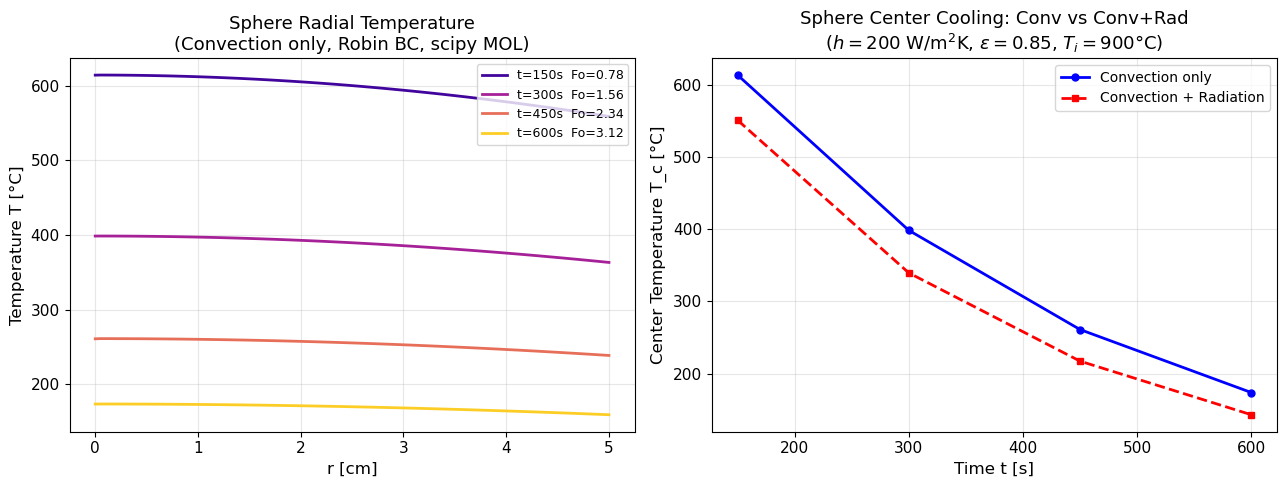

✓ 圖檔已儲存: p3_s2_sphere_radiation.png


In [11]:

# ============================================================
# Part 3 場景二：球體非穩態熱傳 + 對流+輻射邊界
# scipy Method of Lines (MOL) + SphericalSymGrid (for reference)
# ============================================================

from scipy.integrate import solve_ivp
from matplotlib import cm as mpl_cm

R_sph    = 0.05         # 球半徑 [m]
k_sph    = 50.0         # W/m·K
rho_cp_s = 3.84e6       # J/m³·K
alpha_sp = k_sph / rho_cp_s
h_sph    = 200.0        # W/m²·K
eps_sph  = 0.85         # 表面輻射率
sigma_sb = 5.67e-8      # Stefan-Boltzmann [W/m²·K⁴]
T_i_sp   = 900.0        # °C
T_inf_sp = 20.0         # °C
Nr_sph   = 100
t_sph    = 600.0        # s

# 均勻節點 r[0]=0 (球心), r[-1]=R (表面)
r_arr_sp = np.linspace(0.0, R_sph, Nr_sph)
dr_sp    = r_arr_sp[1] - r_arr_sp[0]
T_sp_init = np.full(Nr_sph, T_i_sp)

# ── 共用 RHS 工廠函數 ──────────────────────────────────────────
def make_sphere_rhs(radiation=False):
    """Return RHS for spherical MOL.  radiation=True adds radiation to surface BC."""
    def rhs(t, T):
        dT = np.zeros_like(T)

        # 球心 i=0: L'Hôpital → dT/dt = 3α×d²T/dr²
        # ghost-cell 對稱邊界：T_ghost=T[1]，d²T/dr²=(T[1]-2T[0]+T[1])/dr²=2(T[1]-T[0])/dr²
        # → dT[0] = α × 3 × 2(T[1]-T[0])/dr² = 6α(T[1]-T[0])/dr²  (二階精度)
        dT[0] = alpha_sp * 6.0 * (T[1] - T[0]) / dr_sp**2

        # 內部節點 1 .. Nr-2: 球座標 Laplacian
        r_int = r_arr_sp[1:-1]
        dT[1:-1] = alpha_sp * (
            (T[2:] - 2*T[1:-1] + T[:-2]) / dr_sp**2
            + (T[2:] - T[:-2]) / (r_int * dr_sp)   # 2/r * dT/dr
        )

        # 表面節點 i=Nr-1: ghost-cell Robin BC (2nd-order)
        T_s = T[-1]
        q_conv = h_sph * (T_s - T_inf_sp)
        if radiation:
            T_s_K   = T_s   + 273.15
            T_inf_K = T_inf_sp + 273.15
            q_rad   = sigma_sb * eps_sph * (T_s_K**4 - T_inf_K**4)
        else:
            q_rad = 0.0
        q_total = q_conv + q_rad
        # -k dT/dr|_R = q_total → ghost: T_g = T[-2] - 2*dr/k * q_total
        T_ghost = T[-2] - 2.0 * dr_sp / k_sph * q_total
        r_s = r_arr_sp[-1]   # R_sph
        dT[-1] = alpha_sp * (
            (T_ghost - 2*T[-1] + T[-2]) / dr_sp**2
            + (T_ghost - T[-2]) / (r_s * dr_sp)
        )
        return dT
    return rhs

n_sph_shots = 4
t_sph_arr   = np.linspace(0, t_sph, n_sph_shots + 1)[1:]

# ── 純對流（scipy MOL） ───────────────────────────────────────
sol_conv = solve_ivp(
    make_sphere_rhs(radiation=False),
    [0.0, t_sph], T_sp_init.copy(),
    method='RK45', t_eval=t_sph_arr, rtol=1e-4, atol=1e-6, max_step=1.0
)
print(f"✓ 純對流冷卻求解完成  (status={sol_conv.status})")

# ── 對流+輻射（scipy MOL） ─────────────────────────────────────
sol_rad = solve_ivp(
    make_sphere_rhs(radiation=True),
    [0.0, t_sph], T_sp_init.copy(),
    method='RK45', t_eval=t_sph_arr, rtol=1e-4, atol=1e-6, max_step=1.0
)
print(f"✓ 對流+輻射冷卻求解完成 (status={sol_rad.status})")

# ── 繪圖 ──────────────────────────────────────────────────────
colors_sp = mpl_cm.plasma(np.linspace(0.1, 0.9, n_sph_shots))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 左：不同時刻徑向溫度分布（純對流）
for idx in range(n_sph_shots):
    t_val  = t_sph_arr[idx]
    T_prof = sol_conv.y[:, idx]
    Fo_sp  = alpha_sp * t_val / R_sph**2
    axes[0].plot(r_arr_sp * 100, T_prof, color=colors_sp[idx], lw=2,
                 label=f't={t_val:.0f}s  Fo={Fo_sp:.2f}')
axes[0].set_xlabel('r [cm]')
axes[0].set_ylabel('Temperature T [°C]')
axes[0].set_title('Sphere Radial Temperature\n(Convection only, Robin BC, scipy MOL)')
axes[0].legend(fontsize=9)

# 右：中心冷卻曲線比較
T_c_conv = sol_conv.y[0]
T_c_rad  = sol_rad.y[0]
axes[1].plot(sol_conv.t, T_c_conv, 'b-o', ms=5, lw=2, label='Convection only')
axes[1].plot(sol_rad.t,  T_c_rad,  'r--s', ms=5, lw=2, label='Convection + Radiation')
axes[1].set_xlabel('Time t [s]')
axes[1].set_ylabel('Center Temperature T_c [°C]')
axes[1].set_title(
    f'Sphere Center Cooling: Conv vs Conv+Rad\n'
    f'($h={h_sph:.0f}$ W/m$^2$K, $\\varepsilon={eps_sph}$, $T_i={T_i_sp:.0f}$°C)'
)
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'p3_s2_sphere_radiation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ 圖檔已儲存: p3_s2_sphere_radiation.png")


---
## Part 4：進階熱傳模型

### 溫度相依熱傳導係數 $k(T_K)$：非線性熱傳方程式

**統御方程式**： $\rho C_p \dfrac{\partial T}{\partial t} = \nabla \cdot (k(T_K) \nabla T)$

**材料模型**（冪次律）： $k(T_K) = k_0 \left(\dfrac{T_K}{T_{ref}}\right)^n$

其中 $T_K = T[°C] + 273.15$ [K] 為絕對溫度， $T_{ref} = 300$ K。

使用 `scipy` Picard 疊代搭配三對角矩陣直接求解（`solve_banded`），求解**穩態**非線性 $k(T_K)$ 熱傳方程式，比較不同冪次指數 $n$ 對溫度分布的影響。


✓ 非線性 k(T_K) 穩態求解完成（Picard 疊代）


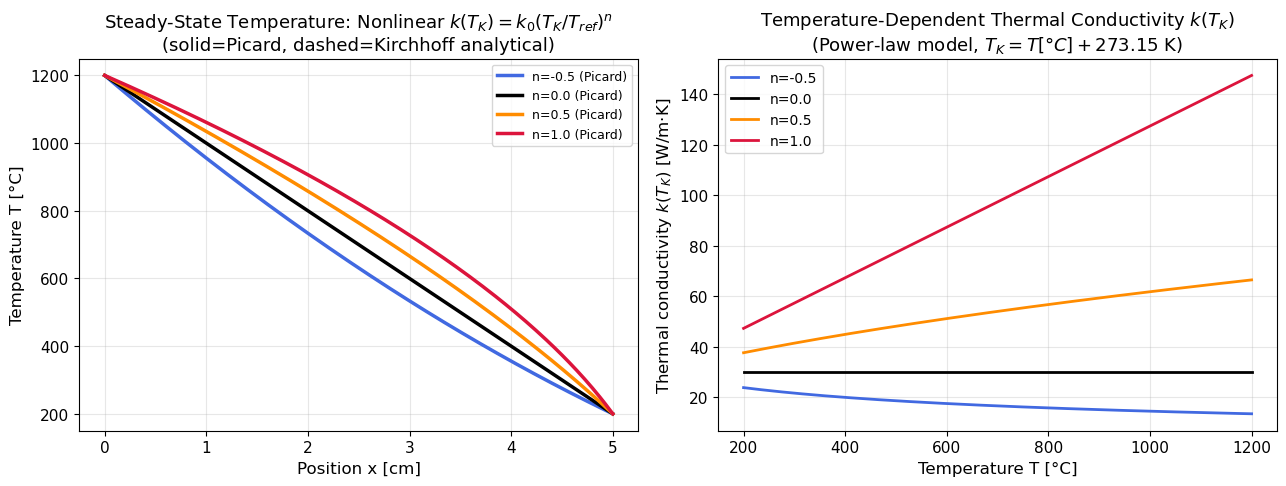

✓ 圖檔已儲存: p4_nonlinear_k.png


In [12]:

# ============================================================
# Part 4：溫度相依熱傳導係數 k(T) 之非線性熱傳
# 使用 Picard 疊代（每步內層三對角矩陣直接求解）求穩態 1D 解
# ============================================================

from scipy.linalg import solve_banded

k0_nl   = 30.0          # 參考熱導率 [W/m·K] at T_ref
T_ref   = 300.0         # 參考溫度 [K] = 27°C
L_nl    = 0.05          # 板厚 [m]
T_hot   = 1200.0        # 左端高溫 [°C]
T_cold  = 200.0         # 右端低溫 [°C]
N_nl    = 200           # 格點數

x_nl  = np.linspace(0, L_nl, N_nl)
dx_nl = x_nl[1] - x_nl[0]

n_values  = [-0.5, 0.0, 0.5, 1.0]  # k(T) 冪次律指數
labels_nl = [f'n={n:.1f}' for n in n_values]
colors_nl = ['royalblue', 'black', 'darkorange', 'crimson']

def solve_nonlinear_k_ss(n_exp):
    """穩態 1D 非線性熱傳：Picard 疊代 + 三對角矩陣法
    
    在每個外層疊代中以 k(T^old) 為已知, 求解線性三對角系統:
        d/dx[k(T^old) * dT/dx] = 0  s.t. T[0]=T_hot, T[-1]=T_cold
    直至收斂 max|T^new - T^old| < 1e-8 °C.
    """
    T = np.linspace(T_hot, T_cold, N_nl)  # 初始猜測：線性分布
    n_int = N_nl - 2  # 內部節點數 (excluding Dirichlet BCs)

    for _ in range(500):
        T_old = T.copy()

        # 界面導熱係數（算術平均，使用絕對溫度 T_K = T+273.15）— 長度 N_nl-1
        k_arr = k0_nl * ((T + 273.15) / T_ref) ** n_exp
        k_hp  = 0.5 * (k_arr[:-1] + k_arr[1:])   # k at face i+1/2

        # 三對角係數（內部節點 j=0..n_int-1，對應 T[j+1]）
        # 方程式: k_hp[j]*T[j-1] - (k_hp[j]+k_hp[j+1])*T[j+1] + k_hp[j+1]*T[j+2] = 0
        main_d  = -(k_hp[:n_int] + k_hp[1:n_int+1])  # 主對角，長度 n_int
        off_d   =   k_hp[1:n_int]                     # 上/下各一條，長度 n_int-1

        # 右端向量（Dirichlet BC 貢獻移至右側）
        rhs = np.zeros(n_int)
        rhs[0]  -= k_hp[0]     * T_hot
        rhs[-1] -= k_hp[n_int] * T_cold

        # 帶狀求解 (1, 1) 帶: [upper_diag, main_diag, lower_diag]
        ab = np.zeros((3, n_int))
        ab[0, 1:]  = off_d    # upper
        ab[1, :]   = main_d   # main
        ab[2, :-1] = off_d    # lower (symmetric)

        T_int = solve_banded((1, 1), ab, rhs)
        T     = np.concatenate([[T_hot], T_int, [T_cold]])

        if np.max(np.abs(T - T_old)) < 1e-8:
            break

    return T

T_profiles = {}
for n_e, label, color in zip(n_values, labels_nl, colors_nl):
    T_nl = solve_nonlinear_k_ss(n_e)
    T_profiles[label] = T_nl

print("✓ 非線性 k(T_K) 穩態求解完成（Picard 疊代）")

# ── 解析解驗證（Kirchhoff transformation）─────────────────────
# φ = ∫_T_cold^T k(T')dT' = k0/T_ref^n * [T_K^(n+1) - T_cold_K^(n+1)] / (n+1)
# φ 為線性 → T 由反轉換求得

def kirchhoff_analytical(n_exp, x):
    """以 Kirchhoff 轉換求解穩態非線性熱傳（n≠-1）"""
    TH_K  = T_hot  + 273.15
    TC_K  = T_cold + 273.15
    def phi(T_K):
        return k0_nl / (n_exp + 1) * (T_K**(n_exp+1) - TC_K**(n_exp+1)) / T_ref**n_exp
    phi_H = phi(TH_K)
    phi_C = phi(TC_K)  # = 0
    phi_x = phi_H + (phi_C - phi_H) * x / L_nl  # linear in x

    # 逆轉換：T_K = [(φ*(n+1)*T_ref^n/k0 + TC_K^(n+1))]^(1/(n+1))
    T_K = ((phi_x * (n_exp + 1) * T_ref**n_exp / k0_nl)
           + TC_K**(n_exp+1)) ** (1 / (n_exp + 1))
    return T_K - 273.15

# ── 繪圖 ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 左圖：穩態溫度分布
for n_e, label, color in zip(n_values, labels_nl, colors_nl):
    axes[0].plot(x_nl * 100, T_profiles[label],
                 color=color, lw=2.5, label=f'{label} (Picard)')
    if abs(n_e + 1) > 0.05:   # 排除 n=-1（無此情況）
        T_ana = kirchhoff_analytical(n_e, x_nl)
        axes[0].plot(x_nl * 100, T_ana,
                     color=color, lw=1.2, ls='--', alpha=0.7)

axes[0].set_xlabel('Position x [cm]')
axes[0].set_ylabel('Temperature T [°C]')
axes[0].set_title(f'Steady-State Temperature: Nonlinear $k(T_K)=k_0(T_K/T_{{ref}})^n$\n'
                   f'(solid=Picard, dashed=Kirchhoff analytical)')
axes[0].legend(fontsize=9)

# 右圖：k(T_K) 隨溫度的變化
T_range_nl = np.linspace(T_cold, T_hot, 200)
for n_e, label, color in zip(n_values, labels_nl, colors_nl):
    k_T = k0_nl * ((T_range_nl + 273.15) / T_ref) ** n_e
    axes[1].plot(T_range_nl, k_T, color=color, lw=2, label=label)
axes[1].set_xlabel('Temperature T [°C]')
axes[1].set_ylabel('Thermal conductivity $k(T_K)$ [W/m·K]')
axes[1].set_title('Temperature-Dependent Thermal Conductivity $k(T_K)$\n'
                   '(Power-law model, $T_K = T[°C]+273.15$ K)')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'p4_nonlinear_k.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ 圖檔已儲存: p4_nonlinear_k.png")


---
## 結語：Fourier's Law 熱傳求解工具選擇指引

| 問題類型 | 幾何形狀 | 推薦工具 | 理由 |
|---------|---------|---------|------|
| 1D 熱傳導（常數 $k$）| 平板 | `py-pde DiffusionPDE` | 簡單高效，解析解驗證方便 |
| 1D 穩態含熱源（Poisson）| 任意 | `scipy.linalg.solve()` | 直接矩陣法，計算快速 |
| 1D Robin 邊界（對流）| 平板/圓柱/球體 | `py-pde` 自訂 BC | 原生支援三類邊界條件 |
| 2D 直角座標非穩態熱傳 | 矩形 | `py-pde CartesianGrid` | 自動處理多維 Laplacian |
| 2D 穩態熱傳（Laplace）| 矩形 | `scipy.sparse.linalg.spsolve` | 有限差分矩陣法，速度最快 |
| 2D 軸對稱熱傳 | 圓柱體 | `py-pde CylindricalSymGrid` | 原生支援圓柱座標 |
| 3D 球體熱傳（球對稱）| 球形 | `scipy` MOL + ghost-cell Robin BC | 含輻射非線性邊界，降維至 1D 徑向 ODE 系統 |
| 3D 直角座標熱傳 | 立方體 | `py-pde CartesianGrid` (3D) + Dirichlet BC | 適合 $Bi\to\infty$ 上界估算，建議網格 $\leq 50^3$ |
| 非線性 $k(T_K)$ 熱傳 | 規則幾何 | `scipy` Picard + `solve_banded` | 穩定收斂，每步求解三對角線性系統，Kirchhoff 變換驗證 |
| 複雜幾何、多材質介面 | 任意 | COMSOL Heat Transfer FEM | 任意幾何精確有限元素 |
| 輻射-對流-導熱全耦合 | 任意 | COMSOL Heat Transfer | 完整物理場耦合求解 |

**核心原則**：`py-pde + scipy` 組合適合**規則幾何、均勻材質**的 Fourier 熱傳教學與工程快速估算；面對**複雜幾何、多材質界面、輻射耦合或非線性材料性質**等工業級精度需求，建議使用 COMSOL Heat Transfer 模組。

---

**課程資訊**
- 課程名稱：電腦在化工上之應用 (ChemE 3502)
- 課程單元：Unit 10 偏微分方程式 (PDE) 數值方法 — Fourier's Law 熱量傳遞方程式之數值模擬
- 課程製作：逢甲大學 化工系 智慧程序系統工程實驗室
- 授課教師：莊曜禎 助理教授
- 更新日期：2026-02-23
